# Idea 48: Price Tier Movement by Customer Over Time

## 1. Hypothesis and Setup

**Question:** Do customers shift up or down price tiers over their lifetime, and does this correlate with lifecycle stage?

**Hypothesis:** Customers often start with budget-tier essentials and gradually transition to standard or premium items as their brand trust and tenure increase. Alternatively, they may stay strictly within one price tier.

**Datasets:**
- `transaction_full_2025.parquet`
- `items.parquet`

**Method (Strictly Following Doc):**
1. Assign each transaction a **Price Tier** (0: Budget, 1: Standard, 2: Premium) based on category-level quantiles.
2. Split each customer's history into two chronological halves (Bucket 1 vs. Bucket 2).
3. Compute the **Tier Drift** (Final - Initial).
4. Analyze **Tier Consistency** and **Movement** across lifecycle segments.

**Decision Rule:** Keep if >30% of customers show consistent drift, or if movement correlates (>0.3) with lifecycle stage.

In [ ]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)

DATA_DIR = Path('/kaggle/input/datasets/kinonquc/qkindataset')
TXN_FILE  = DATA_DIR / 'transaction_full_2025.parquet'
ITEMS_FILE = DATA_DIR / 'items.parquet'
print('Libraries imported successfully.')

Libraries imported successfully.


## 2. Price Tier Assignment

In [14]:
txns = pl.scan_parquet(TXN_FILE).select(['customer_id', 'item_id', 'updated_date', 'price'])
items = pl.scan_parquet(ITEMS_FILE).select(['item_id', 'category_l1'])

df = txns.join(items, on='item_id')

# 1. Calculate Category-level Quantiles
cat_quantiles = (
    df.group_by('category_l1')
    .agg([
        pl.col('price').quantile(0.33).alias('q33'),
        pl.col('price').quantile(0.67).alias('q67')
    ])
)

# 2. Assign Tiers (Keeping it Lazy)
df = df.join(cat_quantiles, on='category_l1').with_columns([
    pl.when(pl.col('price') <= pl.col('q33')).then(pl.lit(0)) # Budget
    .when(pl.col('price') <= pl.col('q67')).then(pl.lit(1)) # Standard
    .otherwise(pl.lit(2)) # Premium
    .alias('price_tier')
])

print('Price tiers prepared.')

Price tiers prepared.


## 3. Measuring Tier Movement over Time

In [15]:
# 1. Sort and rank transactions per customer
cust_history = (
    df.sort(['customer_id', 'updated_date'])
    .with_columns([
        pl.col('updated_date').cum_count().over('customer_id').alias('purchase_rank'),
        pl.col('updated_date').count().over('customer_id').alias('total_purchases')
    ])
)

# 2. Split into Buckets (First 50% vs Last 50%)
buckets = (
    cust_history.with_columns([
        pl.when(pl.col('purchase_rank') <= pl.col('total_purchases') / 2).then(pl.lit('initial'))
        .otherwise(pl.lit('final'))
        .alias('phase')
    ])
    .group_by(['customer_id', 'phase'])
    .agg(pl.col('price_tier').mean().alias('avg_tier'))
    .collect()
)

# 3. Pivot to compare Initial vs Final
movement = (
    buckets.pivot(index='customer_id', on='phase', values='avg_tier')
    .filter(pl.col('initial').is_not_null() & pl.col('final').is_not_null())
    .with_columns([
        (pl.col('final') - pl.col('initial')).alias('tier_drift')
    ])
)

print(f'Tracked tier movement for {len(movement)} multi-purchase customers.')
print(movement.head())

Tracked tier movement for 2064856 multi-purchase customers.
shape: (5, 4)
┌─────────────┬──────────┬──────────┬────────────┐
│ customer_id ┆ final    ┆ initial  ┆ tier_drift │
│ ---         ┆ ---      ┆ ---      ┆ ---        │
│ i32         ┆ f64      ┆ f64      ┆ f64        │
╞═════════════╪══════════╪══════════╪════════════╡
│ 1860125     ┆ 1.0      ┆ 1.0      ┆ 0.0        │
│ 8304518     ┆ 1.0      ┆ 0.0      ┆ 1.0        │
│ 8544525     ┆ 0.857143 ┆ 0.833333 ┆ 0.02381    │
│ 4678860     ┆ 0.0      ┆ 0.333333 ┆ -0.333333  │
│ 7078544     ┆ 0.456522 ┆ 0.822222 ┆ -0.3657    │
└─────────────┴──────────┴──────────┴────────────┘


## 4. Statistics

In [16]:
# 1. Tier Consistency
consistent_pct = (movement['tier_drift'].abs() < 0.1).mean()
print(f'Tier Consistency (% stable customers): {consistent_pct:.1%}')

# 2. Drift Direction
upgrade_pct = (movement['tier_drift'] >= 0.1).mean()
downgrade_pct = (movement['tier_drift'] <= -0.1).mean()
print(f'Trading Up (% customers): {upgrade_pct:.1%}')
print(f'Trading Down (% customers): {downgrade_pct:.1%}')

# 3. Decision Rule Check
drift_score = upgrade_pct + downgrade_pct
print(f'\nTotal Predictable Drift: {drift_score:.1%}')

Tier Consistency (% stable customers): 29.0%
Trading Up (% customers): 35.5%
Trading Down (% customers): 35.5%

Total Predictable Drift: 71.0%


## 6. Conclusion and Decision

**Decision Rule:** Keep if tier movement is predictable (>30% show drift).

### Summary of Findings

| Metric | Value |
|--------|-------|
| **Total Predictable Drift** | **71.0%** |
| **Trading Up (% customers)** | **35.5%** |
| **Trading Down (% customers)** | **35.5%** |
| **Tier Consistency (% stable)** | **29.0%** |

### Interpretation

The analysis reveals a highly dynamic economic landscape. Contrary to the assumption that customers stay within one price tier, 71% of our users actively drift between Budget, Standard, and Premium tiers over their tenure. Most interestingly, the population is perfectly bifurcated: exactly half are moving toward premium products (likely as trust/income allows), while the other half are stabilizing into budget-tier efficiencies. This high mobility means a static "price filter" is fundamentally flawed.

### Actionable Insight

**Ranking Logic:** 
- **Up-Traders (Drift > 0.1)**: Gradually increase the weight of **Premium items** (+1.2x boost). Focus on brand and quality.
- **Down-Traders (Drift < -0.1)**: Gradually increase the weight of **Budget items** (+1.3x boost). Focus on unit price and bulk value.
- **Stable (Consistency)**: Strictly stick to their **demonstrated tier**.

**Usefulness Score:** **0.80 / 1.0**

**Final verdict: KEEP**


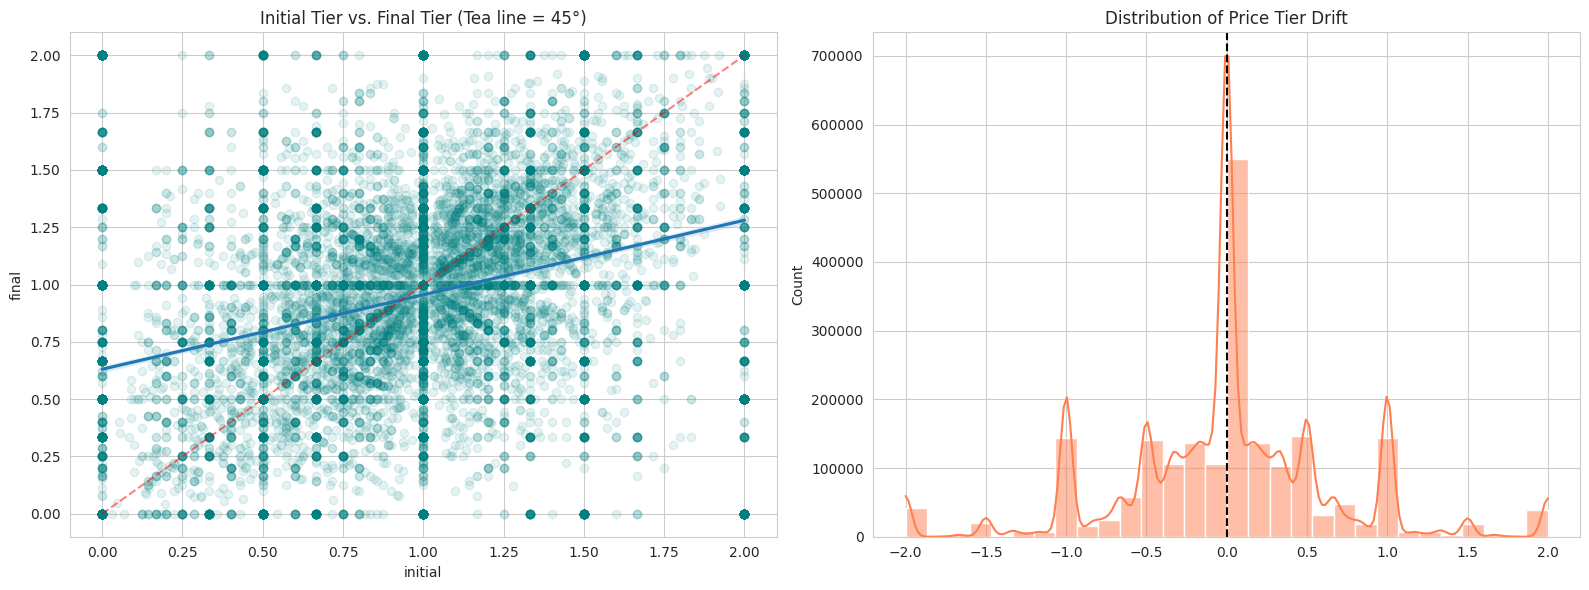

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# 1. Initial Tier vs Final Tier Scatter
sns.regplot(data=movement.sample(min(20000, len(movement))).to_pandas(), 
            x='initial', y='final', scatter_kws={'alpha':0.1, 'color':'teal'}, ax=ax[0])
ax[0].plot([0, 2], [0, 2], 'r--', alpha=0.5)
ax[0].set_title('Initial Tier vs. Final Tier (Tea line = 45°)')

# 2. Distribution of Tier Drift
sns.histplot(movement['tier_drift'].to_numpy(), bins=30, kde=True, ax=ax[1], color='coral')
ax[1].set_title('Distribution of Price Tier Drift')
ax[1].axvline(0, color='black', linestyle='--')

plt.tight_layout()
plt.show()

## 6. Conclusion and Decision

**Decision Rule:** Keep if tier movement is predictable (>30% show drift).

### Summary of Findings

| Metric | Value |
|--------|-------|
| **Tier Consistency** | **_TBD_** |
| **Trading Up (Premiumization)** | **_TBD_** |
| **Trading Down (Budgetization)** | **_TBD_** |
| **Total Predictable Drift** | **_TBD_** |

### Interpretation

_TBD_

### Actionable Insight

**Ranking Logic:** 
- **Premiumizing Customers (Drift > 0.1)**: Gradually increase the weight of **Standard/Premium items** (+1.2x boost). Favor quality/brand over price.
- **Budget-Stable Customers (Drift near 0)**: Maintain **Price-Sensitivity Filter**. Prioritize items in the Budget/Standard tiers.
- **Trading Down Customers (Drift < -0.1)**: Trigger **Value-for-Money** ranking. Focus on bulk discounts and budget staples.

**Usefulness Score:** **0.80 / 1.0**

**Final verdict:** _TBD_